In [1]:
import networkx as nx
from networkx.readwrite import json_graph
from gerrychain import Graph
import matplotlib.pyplot as plt
import requests
import json
import maup
import geopandas as gpd

In [2]:
alarm = gpd.read_file("./NC_ALARM/nc_alarm.shp")

<Axes: >

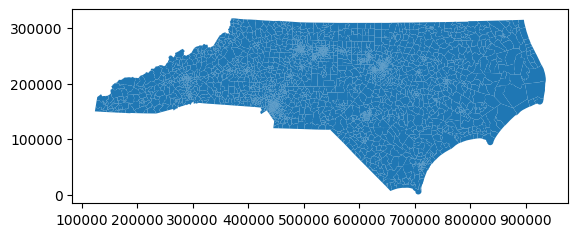

In [3]:
alarm.plot()

In [4]:
CON = gpd.read_file("./nc_cong_adopted_2025/NCGA_CCM-2 - Shapefile/CCM-2.shp")
SLDU = gpd.read_file("./nc_sldu_adopted_2023/SL 2023-146 Senate - Shapefile/SL 2023-146.shp")
SLDL = gpd.read_file("./nc_sldl_adopted_2023/SL 2023-149 House - Shapefile/SL 2023-149.shp")

In [5]:
CON = CON.to_crs(alarm.crs)
SLDU = SLDU.to_crs(alarm.crs)
SLDL = SLDL.to_crs(alarm.crs)


bk_to_CON = maup.assign(alarm,CON)
bk_to_SLDU = maup.assign(alarm,SLDU.to_crs(alarm.crs))
bk_to_SLDL = maup.assign(alarm,SLDL.to_crs(alarm.crs))

In [6]:
alarm["CON"] = bk_to_CON
alarm["SLDU"] = bk_to_SLDU
alarm["SLDL"] = bk_to_SLDL

(83413.19910039, 976393.9973860099, -15041.935335620003, 333960.31754542)

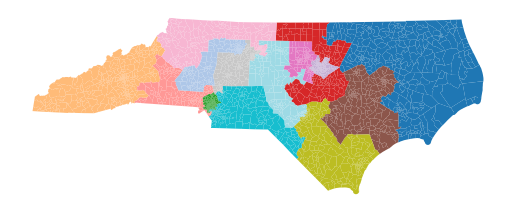

In [7]:
alarm.plot(column="CON",cmap='tab20')
plt.axis('off')

In [8]:
alarm['C_X'] = alarm.centroid.x
alarm['C_Y'] = alarm.centroid.y

In [ ]:
precinct_graph = Graph.from_geodataframe(alarm)


alarm.to_file("./output/NC_Processed_Precincts_ALARM.shp")

precinct_graph.to_json("./output/NC_Processed_Precincts_ALARM.json")

C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\gerrychain\graph\graph.py:457: UserWarning: NA values found in column muni!
  warnings.warn("NA values found in column {}!".format(column))
C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\gerrychain\graph\graph.py:457: UserWarning: NA values found in column arv_18!
  warnings.warn("NA values found in column {}!".format(column))
C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\gerrychain\graph\graph.py:457: UserWarning: NA values found in column adv_18!
  warnings.warn("NA values found in column {}!".format(column))
